# División de los mecanizados de cada una de las herramientas

### Importamos las librerías

In [1]:
from File2PandasTable import File2PandasTable
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from funciones_mecanizados import separar_mecanizados

%matplotlib inline

import pandas as pd
import importlib
import copy

pd.options.display.float_format = "{:.3f}".format

### Cargamos los datos

In [2]:
data_H1_file = 'data/panel1_H1.TXT'
data_H2_file = 'data/panel2_H2.TXT'
data_H3_file = 'data/panel1_H3.TXT'
data_H3_file_ = 'data/panel2_H3.TXT'

h1 = File2PandasTable(data_H1_file) # Broca muy usada
h2 = File2PandasTable(data_H2_file) # Broca usada
h3 = File2PandasTable(data_H3_file) # Broca nueva
h3_ = File2PandasTable(data_H3_file_) # Broca nueva 2da medición

print('h1:', h1.shape)
print('h2:', h2.shape)
print('h3:', h3.shape)
print('h3_:', h3_.shape)

print('Parámetros:',list(h1.columns))

h1: (18070, 20)
h2: (8308, 20)
h3: (7635, 20)
h3_: (7948, 20)
Parámetros: ['ID', 'Tiempo', 'PARA1', 'CH', 'RISE', 'COUN', 'ENER', 'DURATION', 'AMP', 'A_FRQ', 'RMS', 'ASL', 'PCNTS', 'THR', 'R_FRQ', 'I_FRQ', 'SIG_STRNGTH', 'ABS_ENERGY', 'C_FRQ', 'P_FRQ']


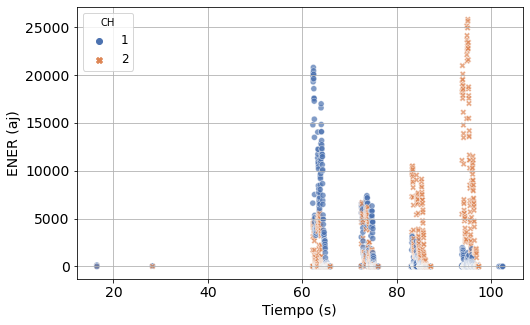

In [3]:
# Plot dataset
plt.figure(figsize=(8,5))
var = 'ENER'
data = h3

sns.scatterplot(data=data, x='Tiempo', y=var, hue='CH', palette='deep', style="CH", alpha=0.7)

plt.legend(title='CH', loc=2, fontsize=12)
plt.ylabel('ENER (aj)',fontsize=14)
plt.xlabel('Tiempo (s)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid('True')

## Dividimos los mecanizados

In [4]:
data_h1 = separar_mecanizados(h1)
data_h2 = separar_mecanizados(h2)
data_h3 = separar_mecanizados(h3)
data_h3_ = separar_mecanizados(h3_)

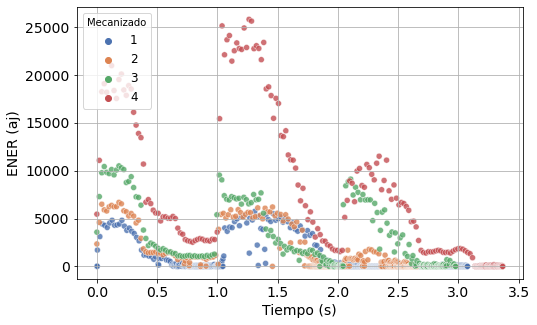

In [5]:
#Plot dataset separado por mecanizados
plt.figure(figsize=(8,5))
var = 'ENER'
ch = 2
data=data_h3

sns.scatterplot(data=data[data['CH']==ch], x='Tiempo', y=var, hue='Mecanizado', palette='deep', alpha=0.8)
plt.legend(title='Mecanizado', loc=2, fontsize=12)
plt.ylabel('ENER (aj)',fontsize=14)
plt.xlabel('Tiempo (s)',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid('True')

In [6]:
# Elminamos las columnas que no vamos a usar.
data_h1.drop(['PARA1','ID','THR'], axis=1, inplace=True)
data_h2.drop(['PARA1','ID','THR'], axis=1, inplace=True)
data_h3.drop(['PARA1','ID','THR'], axis=1, inplace=True)
data_h3_.drop(['PARA1','ID','THR'], axis=1, inplace=True)

# Agregamos una etiqueta indicando la condición de la broca
data_h1['Herramienta'] = 'Muy Usada'
data_h2['Herramienta'] = 'Usada'
data_h3['Herramienta'] = 'Nueva'
data_h3_['Herramienta'] = 'Nueva'

### Exportamos los DataFrames a archivos CSV

In [7]:
data_h1.to_csv(r'data/panel1_H1.csv', index=False)
data_h2.to_csv(r'data/panel2_H2.csv', index=False)
data_h3.to_csv(r'data/panel1_H3.csv', index=False)
data_h3_.to_csv(r'data/panel2_H3.csv', index=False)